In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2

In [ ]:
img = cv2.imread("C:\\Users\\ayush\\OneDrive\\Desktop\\_\\Codes\\CP 4 Lab\\test_cat.png", cv2.IMREAD_GRAYSCALE)
U, W, VT = np.linalg.svd(img)

print(f"W is {W.ndim}D")
print(W)

print("original image")
print(img)
print(f"Shape(A)  : {img.shape}")
print(f"Shape(U) : {U.shape}")
print(f"Shape(W) : {W.shape}")
print(f"Shape(VT) : {VT.shape}")

W is 2D
[[3214.87238142  302.94569084   30.52015069]
 [3225.59397161  302.76254358   30.89291964]
 [3233.71967828  302.7019585    30.58703405]
 ...
 [4499.42522631   81.05552158   19.63759787]
 [4502.95954226   81.75367213   19.33126729]
 [4509.7071631    81.89705255   19.05717276]]
original image
[[[  1   8  41]
  [  1  11  45]
  [  1  13  49]
  ...
  [108 124 140]
  [108 124 140]
  [108 124 140]]

 [[  7  20  55]
  [ 11  26  62]
  [ 21  35  71]
  ...
  [108 124 140]
  [108 124 140]
  [108 124 140]]

 [[ 21  40  77]
  [ 26  45  82]
  [ 32  50  89]
  ...
  [109 125 141]
  [109 125 141]
  [109 125 141]]

 ...

 [[ 40  47  56]
  [ 40  47  56]
  [ 40  46  57]
  ...
  [ 55  62  71]
  [ 55  62  71]
  [ 58  64  73]]

 [[ 40  47  56]
  [ 40  47  56]
  [ 40  46  57]
  ...
  [ 58  65  74]
  [ 58  66  75]
  [ 58  64  73]]

 [[ 40  47  56]
  [ 40  47  57]
  [ 39  45  56]
  ...
  [ 56  63  72]
  [ 57  64  73]
  [ 55  62  71]]]
Shape(A)  : (360, 360, 3)
Shape(U) : (360, 360, 360)
Shape(W) : (360, 3


singular values threshold (in percent):    50.0%
Number of singular values used( shape of W): 2
percent of 2th singular values : 50.57814699591113%

singular values threshold (in percent):    90.0%
Number of singular values used( shape of W): 51
percent of 51th singular values : 90.15905164040343%

singular values threshold (in percent):    99.0%
Number of singular values used( shape of W): 213
percent of 213th singular values : 99.01212061839638%

singular values threshold (in percent):    100.0%
Number of singular values used( shape of W): 360
percent of 360th singular values : 100.0%


C:\Users\ayush\AppData\Local\Temp\ipykernel_22832\4210852758.py:27: RuntimeWarning: divide by zero encountered in log
  axes[0,i].plot(np.log(range(len(W[:nv]))), (W[:nv]), "o-", label =" log scaled")


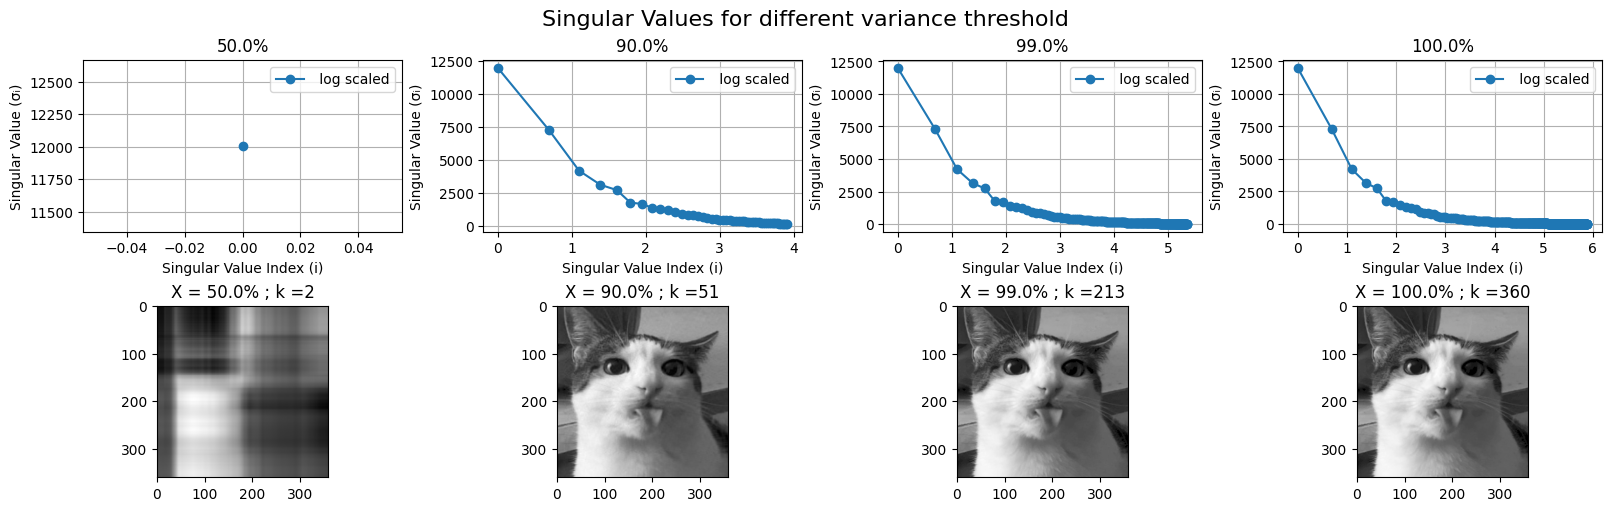

In [4]:
perc = [ .5, .9, .99, 1.0]
img_arr = []
nv_arr = []

fig, axes = plt.subplots(2, len(perc), figsize =(16, 5), constrained_layout=True)
fig.suptitle("Singular Values for different variance threshold", fontsize=16)

for i, p in enumerate(perc):

    exp_var = (W) / np.sum(W) # explainedn variance
    cum_vare = np.cumsum(exp_var) # cumulative summation

    nv = np.argmax(cum_vare >= p) + 1 # number of W required
    nv_var = cum_vare[nv-1]

    new_W, new_U, new_VT = np.diag(W[:nv]), U[:,:nv], VT[:nv, :]
    new_img = new_U @ new_W @ new_VT

    print(f"\nsingular values threshold (in percent):    {p*100}%")
    print(f"Number of singular values used( shape of W): {nv}")
    print(f"percent of {nv}th singular values : {nv_var*100}%")
    
    img_arr.append(new_img)
    nv_arr.append(nv)

    # axes[i].plot(range(len(W[:nv])), W[:nv], 'o-', label =" linear scaled")
    axes[0,i].plot(np.log(range(len(W[:nv]))), (W[:nv]), "o-", label =" log scaled")
    axes[0,i].set_title(f"{p*100}%")
    axes[0,i].set_xlabel("Singular Value Index (i)")
    axes[0,i].set_ylabel("Singular Value (σᵢ)")
    axes[0,i].grid()
    axes[0,i].legend()

# img_arr.append(img)

# fig, axes = plt.subplots(1, len(img_arr), figsize =(16, 5), constrained_layout=True)
# fig.suptitle(f"Images for X% singular values (k singular values)", fontsize=16)

for i, im in enumerate(img_arr):
    axes[1,i].imshow(im, cmap = "gray")
    if i > len(perc)-1:
        axes[1,i].set_title(f"Original Image")
        
    else:
        axes[1,i].set_title(f"X = {perc[i]*100}% ; k ={nv_arr[i]}")